Title: DSC 320 Math for Data Science Assignment 9.2 ; Author: Rachael Biegert ; Date: 16 May 2026 ; Modified By: Rachael Biegert ; Description: This program demonstrates the use of ; NumPy, matplotlib, and pandas to manipulate data frames, calculate probabilities, and plot charts.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/qb_stats.csv")

# Preview the data
print(df.head())

             name team  games    att    cmp  comp_pct     yds  ypa    td  int  \
0  Ryan Tannehill  TEN   12.0  286.0  201.0      70.3  2742.0  9.6  22.0  6.0   
1      Drew Brees   NO   11.0  378.0  281.0      74.3  2979.0  7.9  27.0  4.0   
2   Lamar Jackson  BAL   15.0  401.0  265.0      66.1  3127.0  7.8  36.0  6.0   
3    Kirk Cousins  MIN   15.0  444.0  307.0      69.1  3603.0  8.1  26.0  6.0   
4  Russell Wilson  SEA   16.0  516.0  341.0      66.1  4110.0  8.0  31.0  5.0   

   sack   loss  rating  
0  31.0  212.0   117.5  
1  12.0   89.0   116.3  
2  23.0  106.0   113.3  
3  28.0  206.0   107.4  
4  48.0  319.0   106.3  


##a)

In [3]:
# Calculate only numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# Calculate means
means = numeric_cols.mean()

#Print results
print("Mean of each numerical column:")
print(means)

Mean of each numerical column:
games         14.125000
att          478.406250
cmp          306.562500
comp_pct      64.296875
yds         3515.062500
ypa            7.375000
td            22.375000
int           10.343750
sack          32.312500
loss         217.093750
rating        93.387500
dtype: float64


##b)

In [4]:
# Calculate standard deviations
std_devs = numeric_cols.std()

#Print results
print("\nStandard deviation of each numerical column:")
print(std_devs)


Standard deviation of each numerical column:
games         2.406309
att         110.360366
cmp          68.929575
comp_pct      3.627537
yds         852.437489
ypa           0.796768
td            6.256609
int           5.839849
sack         10.514008
loss         70.786075
rating       11.054725
dtype: float64


##c)


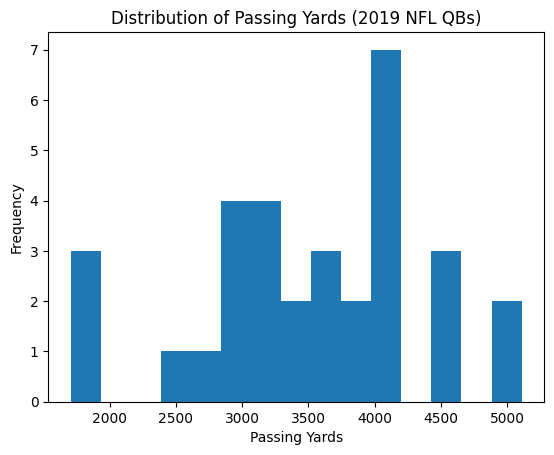

In [5]:
# Create histogram for passing yards
plt.figure()
plt.hist(df['yds'], bins=15)

# Labels and title
plt.xlabel("Passing Yards")
plt.ylabel("Frequency")
plt.title("Distribution of Passing Yards (2019 NFL QBs)")

plt.show()

##d)

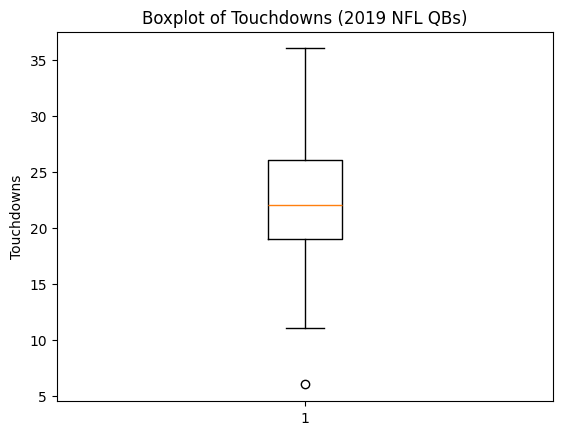


Outliers in td:
          name   td
24  Joe Flacco  6.0


In [6]:
# Create boxplot
plt.figure()
plt.boxplot(df['td'])

# Labels and title
plt.ylabel("Touchdowns")
plt.title("Boxplot of Touchdowns (2019 NFL QBs)")

plt.show()

# Calculate Q1, Q3, and IQR
Q1 = df['td'].quantile(0.25)
Q3 = df['td'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['td'] < lower_bound) | (df['td'] > upper_bound)]

print("\nOutliers in td:")
print(outliers[['name', 'td']])

##2.

In [7]:
# Load dataset
df = pd.read_csv("/content/drive/MyDrive/survey_data.csv")

# Preview data
print(df.head())

  hair_color eye_color
0      brown     brown
1      brown     brown
2      brown      blue
3      brown     green
4      brown     brown


##a)

In [8]:
# Total number of students in the dataset
total = len(df)

# Count students with brown hair
brown_hair_count = len(df[df['hair_color'] == 'brown'])

# Calculate Probability = (number with brown hair) / (total students)
probability_brown_hair = brown_hair_count / total

print("Probability(Brown Hair) =", probability_brown_hair)

Probability(Brown Hair) = 0.5123456790123457


##b)


In [13]:
# Count how many students have blue eyes
blue_eyes_count = len(df[df['eye_color'] == 'blue'])

# Probability = (number with blue eyes) / (total students)
probability_blue_eyes = blue_eyes_count / total

# Print the result
print("Probability(Blue Eyes) =", probability_blue_eyes)

Probability(Blue Eyes) = 0.24691358024691357


##c)


In [20]:
# Count students who have BOTH brown hair AND blue eyes
both_count = len(df[(df['hair_color'] == 'brown') & (df['eye_color'] == 'blue')])

# Conditional probability:
# P(Blue Eyes | Brown Hair) = (# with both) / (# with brown hair)
probability_blue_given_brown = both_count / brown_hair_count

# Print the result
print("Probability(Blue Eyes | Brown Hair) =", probability_blue_given_brown)

Probability(Blue Eyes | Brown Hair) = 0.21686746987951808


##d)


In [15]:
#Calculate the probability a student has brown hair given they have blue eyes
probability_brown_given_blue = (both_count / blue_eyes_count)

# Print the result
print("Probability(Brown Hair | Blue Eyes) =", probability_brown_given_blue)

Probability(Brown Hair | Blue Eyes) = 0.45


##e)


In [16]:
# Print the results to compare values
print("Probabaility(Blue Eyes) =", probability_blue_eyes)
print("Probability(Blue Eyes | Brown Hair) =", probability_blue_given_brown)

Probabaility(Blue Eyes) = 0.24691358024691357
Probability(Blue Eyes | Brown Hair) = 0.21686746987951808


Based on the results, the probability of having blue eyes given brown hair is approximately 22%, while the overall probability of having blue eyes is approximately 25%. Since these values are not equal or noticeably different, this suggests that hair color and eye color are not independent. In other words, knowing someone has brown hair slightly changes the likelihood that they have blue eyes.

##f)

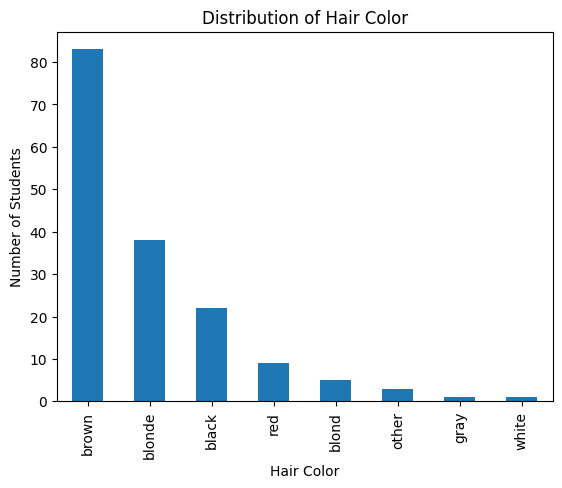

In [17]:
# Count how many students fall into each hair color category
hair_counts = df['hair_color'].value_counts()

# Create a new figure for the bar chart
plt.figure()

# Plot the counts in a bar chart
hair_counts.plot(kind='bar')

# Add labels and title
plt.title("Distribution of Hair Color")
plt.xlabel("Hair Color")
plt.ylabel("Number of Students")

# Display the graph
plt.show()

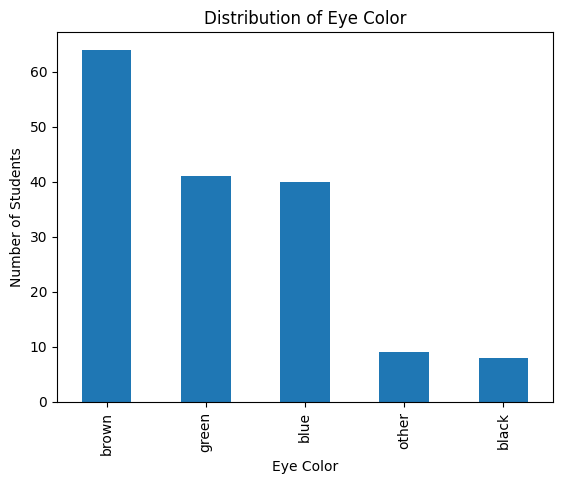

In [18]:
# Count how many students fall into each eye color category
eye_counts = df['eye_color'].value_counts()

# Create a new figure
plt.figure()

# Plot the counts as a bar chart
eye_counts.plot(kind='bar')

# Add labels and title
plt.title("Distribution of Eye Color")
plt.xlabel("Eye Color")
plt.ylabel("Number of Students")

#Print the graph
plt.show()